<a href="https://colab.research.google.com/github/luci-669/machine_learning/blob/main/my_first_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [ ]:
cols = ["fLength","fWidth","fSize","fConc","fConcl","FfAsym","fM3Long","fM3Trans","fAlpha","fdist","Class"]
df = pd.read_csv("magic04.data",names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConcl,FfAsym,fM3Long,fM3Trans,fAlpha,fdist,Class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
df["Class"] = (df["Class"] == "g").astype(int)

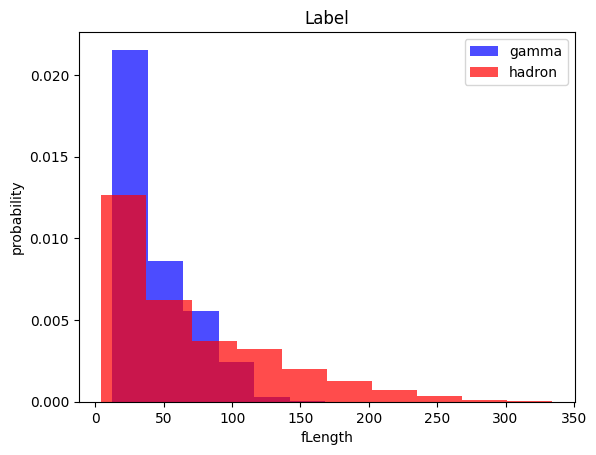

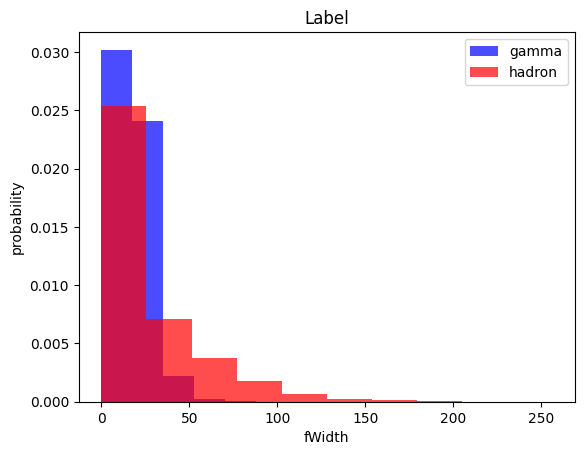

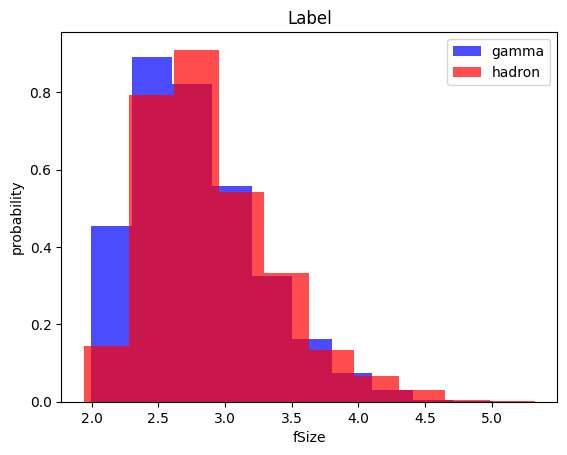

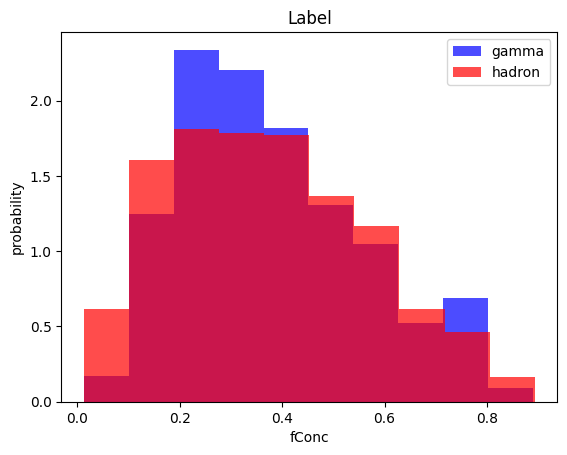

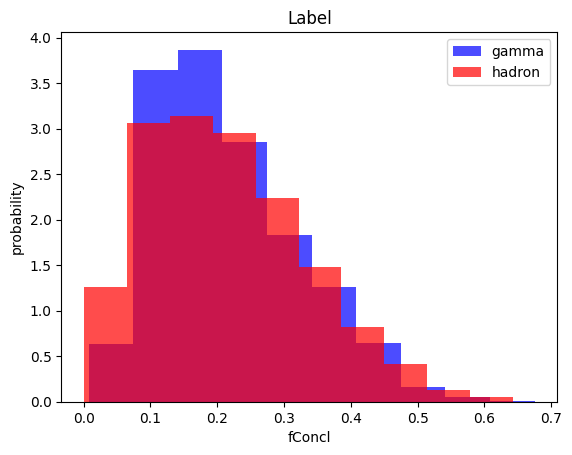

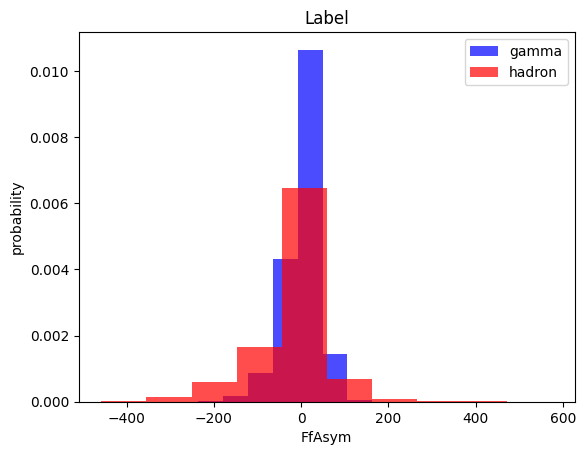

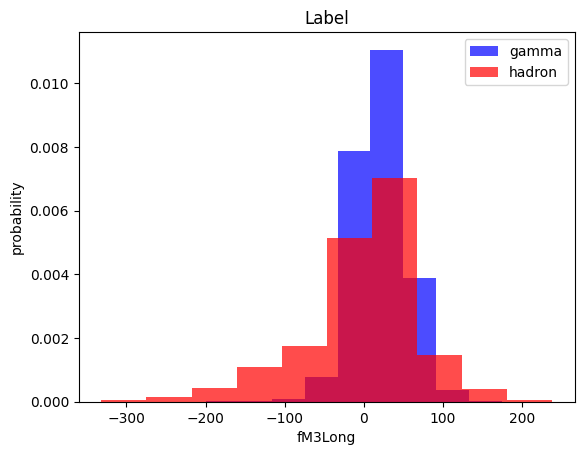

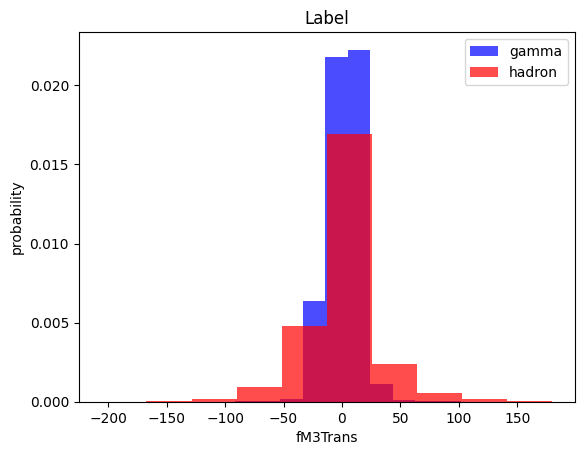

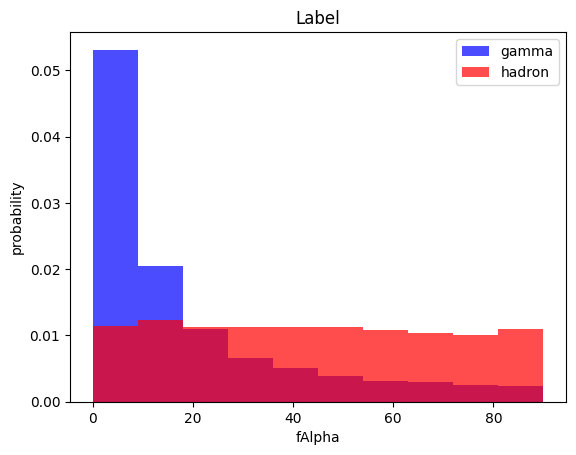

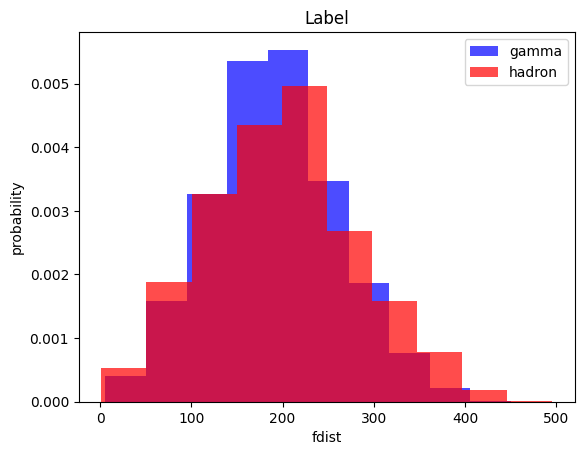

In [ ]:
for label in cols[:-1]:
  plt.hist(df[df["Class"] == 1][label],alpha = 0.7 , label = "gamma", color = "blue",density = True)
  plt.hist(df[df["Class"] == 0][label],alpha = 0.7 , label = "hadron", color = "red",density= True)
  plt.title("Label")
  plt.xlabel(label)
  plt.ylabel("probability")
  plt.legend()
  plt.show()


#Train , Validation and test Dataset


In [ ]:
train , valid , test = np.split(df.sample(frac=1), [int(0.6*len(df)),int(0.8*len(df))])

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
def scale_Dataset(dataframe,oversample):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x , y = ros.fit_resample(x,y)


  data = np.hstack((x,np.reshape(y, (-1,1))))

  return data , x, y



In [ ]:
train ,x_train,y_train = scale_Dataset(train,oversample = True)
valid ,x_valid,y_valid = scale_Dataset(valid,oversample = False)
test ,x_test,y_test = scale_Dataset(test,oversample = False)